In [1]:
from google.colab import files
files.upload()

{}

In [2]:
import os

# Create Kaggle folder
os.makedirs('/root/.kaggle', exist_ok=True)

# Move file to proper location
!mv kaggle.json /root/.kaggle/

# Set permissions
!chmod 600 /root/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
!kaggle datasets download -d jehanbhathena/weather-dataset

Dataset URL: https://www.kaggle.com/datasets/jehanbhathena/weather-dataset
License(s): CC0-1.0
100% 587M/587M [00:15<00:00, 40.3MB/s]



In [4]:
!unzip weather-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: dataset/frost/3913.jpg  
  inflating: dataset/frost/3914.jpg  
  inflating: dataset/frost/3915.jpg  
  inflating: dataset/frost/3916.jpg  
  inflating: dataset/frost/3917.jpg  
  inflating: dataset/frost/3918.jpg  
  inflating: dataset/frost/3919.jpg  
  inflating: dataset/frost/3920.jpg  
  inflating: dataset/frost/3921.jpg  
  inflating: dataset/frost/3922.jpg  
  inflating: dataset/frost/3923.jpg  
  inflating: dataset/frost/3924.jpg  
  inflating: dataset/frost/3925.jpg  
  inflating: dataset/frost/3926.jpg  
  inflating: dataset/frost/3927.jpg  
  inflating: dataset/frost/3928.jpg  
  inflating: dataset/frost/3929.jpg  
  inflating: dataset/frost/3930.jpg  
  inflating: dataset/frost/3931.jpg  
  inflating: dataset/frost/3932.jpg  
  inflating: dataset/frost/3933.jpg  
  inflating: dataset/frost/3934.jpg  
  inflating: dataset/frost/3935.jpg  
  inflating: dataset/frost/3936.jpg  
  inflating: dataset/frost/3937.jpg  

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory, plot_model
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

In [6]:
DATASET_PATH ="dataset"
IMG_SIZE = (128, 128)
BATCH_SIZE =32
EPOCHS = 20

In [7]:
train_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_ds = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 6862 files belonging to 11 classes.
Using 5490 files for training.
Found 6862 files belonging to 11 classes.
Using 1372 files for validation.


In [8]:
#Further split validation -> Validation + test
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

In [9]:
class_names = train_ds.class_names
print(class_names)

['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


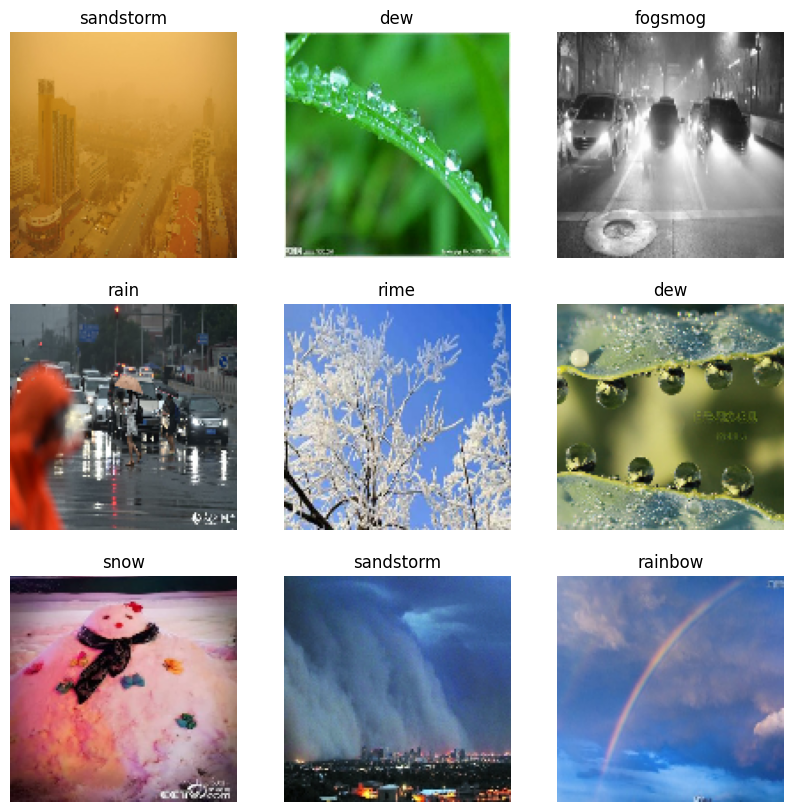

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    plt.subplot(3, 3, i +1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

In [11]:
#Class Distribution
class_counts = {}
for class_name in os.listdir(DATASET_PATH):
  class_counts[class_name] = len(os.listdir(os.path.join(DATASET_PATH, class_name)))
print(class_counts)

{'rainbow': 232, 'sandstorm': 692, 'frost': 475, 'dew': 698, 'fogsmog': 851, 'glaze': 639, 'rain': 526, 'snow': 621, 'lightning': 377, 'rime': 1160, 'hail': 591}


/tmp/ipykernel_1404/2591230093.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=class_df, palette='viridis')


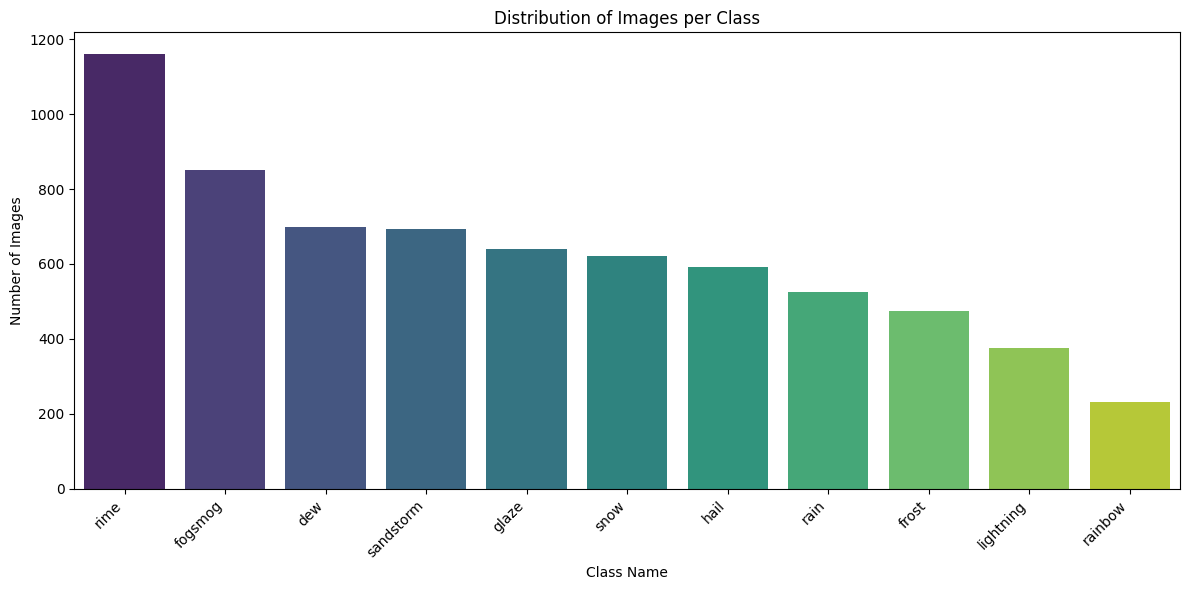

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert class_counts dictionary to a pandas DataFrame for plotting
class_df = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])

# Sort the DataFrame by count for better visualization
class_df = class_df.sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Class', y='Count', data=class_df, palette='viridis')
plt.title('Distribution of Images per Class')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right') # Rotate labels to prevent overlap
plt.tight_layout()
plt.show()

In [13]:
#Normalization
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [14]:
#Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [15]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(filters=64, kernel_size=(3,3),padding="same", activation='relu', input_shape=(128, 128, 3)),
    layers.Conv2D(filters=64, kernel_size=(3,3),padding="same", activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=128, kernel_size=(3,3),padding="same", activation='relu'),
    layers.Conv2D(filters=128, kernel_size=(3,3),padding="same", activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=256, kernel_size=(3,3),padding="same", activation='relu'),
    layers.Conv2D(filters=256, kernel_size=(3,3),padding="same", activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(filters=512, kernel_size=(3,3),padding="same", activation='relu'),
    layers.Conv2D(filters=512, kernel_size=(3,3),padding="same", activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(
        units=4096,
        activation='relu'
    ),
    layers.Dropout(0.5),
    layers.Dense(
        units=4096,
        activation='relu'
    ),
    layers.Dropout(0.5),
    layers.Dense(
        units=len(class_names),
        activation='softmax'
    )
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   134,221,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │        45,067 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,733,579 (594.08 MB)

 Trainable params: 155,733,579 (594.08 MB)

 Non-trainable params: 0 (0.00 B)

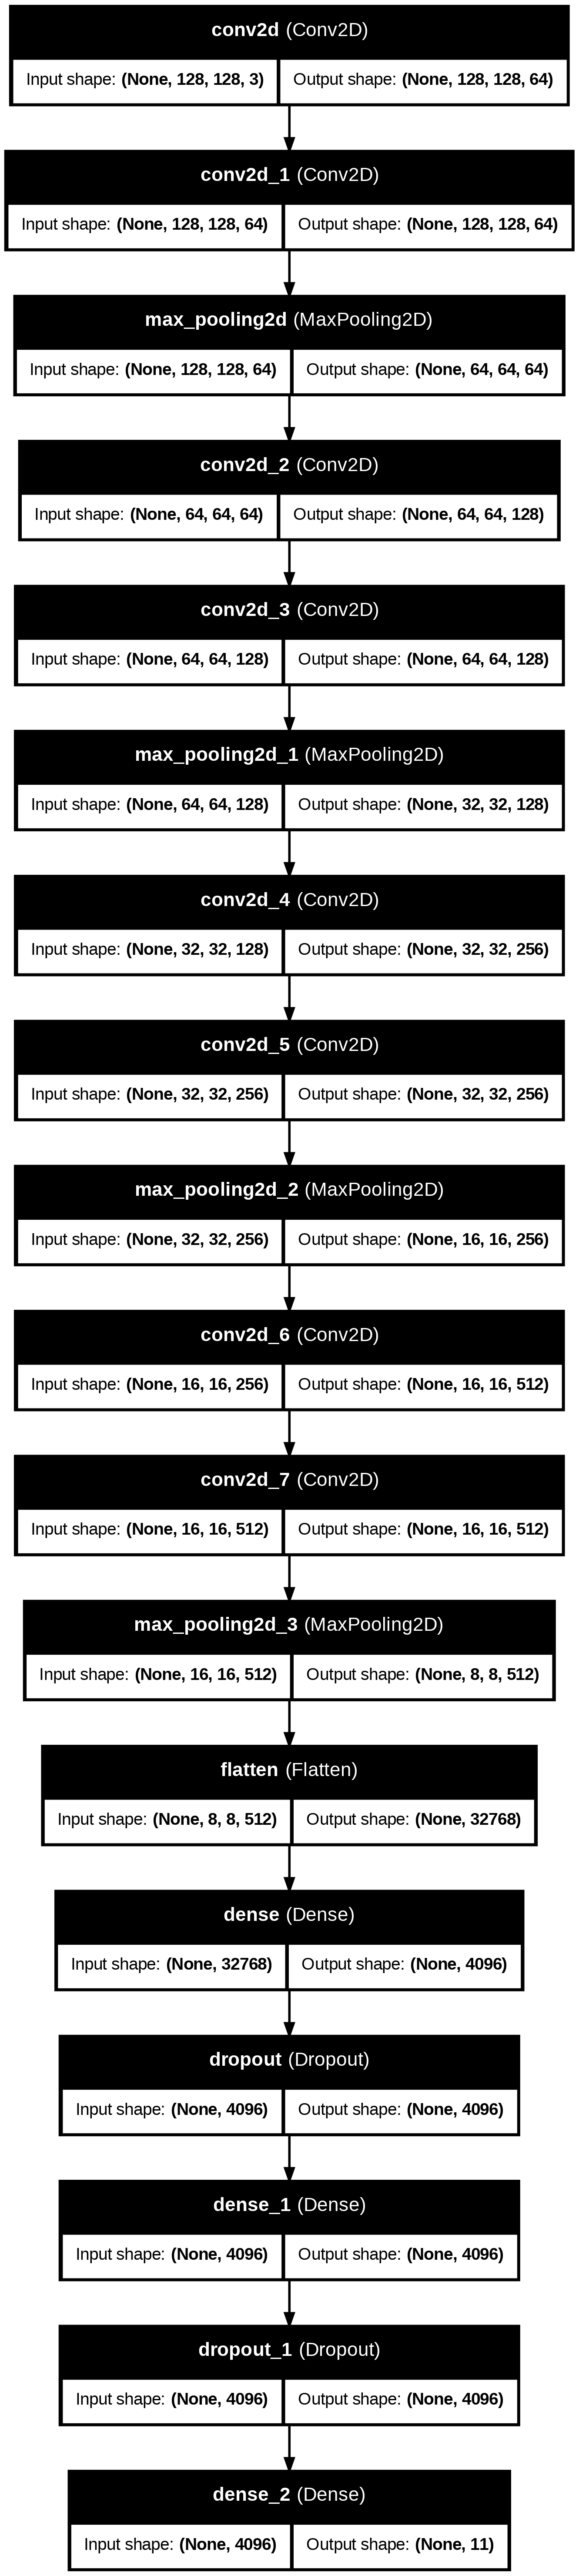

In [16]:
plot_model(model, to_file='model_arch.png', show_shapes=True, show_layer_names=True)

In [17]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [18]:
history=model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 89s 311ms/step - accuracy: 0.2587 - loss: 2.1459 - val_accuracy: 0.3714 - val_loss: 1.8349
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 37s 164ms/step - accuracy: 0.4605 - loss: 1.6418 - val_accuracy: 0.5514 - val_loss: 1.3685
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 38s 169ms/step - accuracy: 0.5370 - loss: 1.3776 - val_accuracy: 0.4929 - val_loss: 1.4072
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 38s 166ms/step - accuracy: 0.5709 - loss: 1.2578 - val_accuracy: 0.5843 - val_loss: 1.2302
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 39s 165ms/step - accuracy: 0.6151 - loss: 1.1317 - val_accuracy: 0.5400 - val_loss: 1.2916
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 39s 166ms/step - accuracy: 0.6379 - loss: 1.0417 - val_accuracy: 0.6300 - val_loss: 1.0866
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 38s 164ms/step - accuracy: 0.6765 - loss: 0.9468 - val_accuracy: 0.6386 - val_loss: 1.0736
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 39s 166ms/step - accuracy: 0.7209 - loss: 0

In [19]:
loss, acc=model.evaluate(test_ds)
print("Test accuracy: ",acc)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.6905 - loss: 1.4954
Test accuracy:  0.6904761791229248


In [20]:
model.save("weather_model.h5")

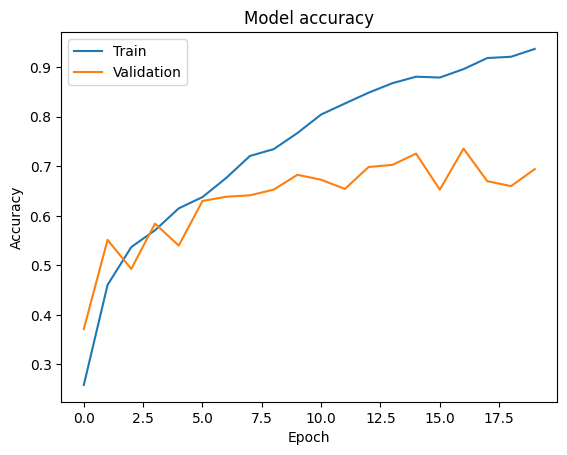

In [21]:
#PLot model accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()